**Tarea 5**

*Mateo Fernández Mier*

**Consensus and Cooperation in Networked Multi-Agent Sytems:**

*Reza Olfati-Saber, J. Alex Fax, and Richard M. Murray*

Este notebook se centrará en la recreación de resultados presentados en el paper [1], principalmente los resultados de la Figura 4 de dicho paper. En tal figura, se demustran la rapidez de convergencia del algoritmo de consenso para tres redes diferentes: una red tipo *small-world*, una red regular con $k=2$ y otra con $k=10$ (siendo $k$ el número de vecinos más cercanos con los que cada nodo de la red está interconectado). 

Para simular estos sistemas, se desarrolló el siguiente código dónde se define la clase *Consensus_Dynamics*. Esta clase se encarga de definir la estructura del grafo utilizando la librería *networkx* (se configuran el número de nodos y el número de $k$ vecinos más cercanos); también, se crea el grafo y se calculan su respectiva matrix Laplaciana y su conectividad algebraica; se definen las dinámicas del algoritmo de consenso, y finalmente se simulan estas dinámicas. 

La distinción entre un grafo tipo *small-world* y un red regular se hace en el código modificando el parámetro $p$ del grafo. Este parámetro corresponde a la probabilidad de *rewiring* del grafo y corresponde a la principal diferencia entre un *small-world* y una *regular lattice*: una red regular presenta una probabilidad de *rewiring* igual a cero ($p=0$).



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.integrate import solve_ivp
plt.rcParams['text.usetex'] = True

class Consensus_Dynamics:

    def __init__(self,number_of_nodes=100,k_nearest_neighbors=6,p=0.0):
        self.n = number_of_nodes
        self.k = k_nearest_neighbors
        self.p = p
    
    def define_graph(self):
        self.G = nx.watts_strogatz_graph(self.n,self.k,self.p,seed=1)
        self.L = nx.laplacian_matrix(self.G).toarray()
        eig = np.sort(np.linalg.eigvals(self.L))
        self.algebraic_connectivity = np.real(eig[1])
        
    def define_dynamics(self,t,x,L):
        rhs = -L @ x
        return rhs
    
    def Simulate_Consensus_Dynamics(self,t_final=10, n_points=1000):
        
        x0 = np.arange(1,self.n+1)
        t_eval = np.linspace(0,t_final,n_points)

        sol = solve_ivp(self.define_dynamics,[0,t_final],x0,args=(self.L,),t_eval=t_eval)

        self.t_sol, self.x_sol = sol.t, sol.y


def Plotting_results(list_of_graphs=None, graph_titles=None, consensus_titles=None,figsize=(5,5),node_size=20,
                     linewidth=1.0,file_name=None):
    
    """
    Plot:
        - Top row: graph topologies
        - Bottom row: consensus trajectories
    
    Parameters
    ----------
    list_of_graphs : list
        List of Consensus_Dynamics objects
    
    graph_titles : list
        Titles for graph plots
    
    consensus_titles : list
        Titles for consensus plots
    
    figsize : tuple
        Size of each subplot block
    
    node_size : int
        Node size in graph visualization
    
    linewidth : float
        Width of trajectory lines
    """

    if list_of_graphs is None:
        print("No graphs provided.")
        return

    N_graphs = len(list_of_graphs)

    # =========================================================
    # DEFAULT TITLES
    # =========================================================

    if graph_titles is None:
        graph_titles = [f"Graph {i+1}" for i in range(N_graphs)]

    if consensus_titles is None:
        consensus_titles = [f"Consensus {i+1}" for i in range(N_graphs)]

    # =========================================================
    # FIGURE
    # =========================================================

    fig, axs = plt.subplots(2,N_graphs,figsize=(figsize[0]*N_graphs, figsize[1]*2)
    )

    # Special case when only one graph is provided
    if N_graphs == 1:
        axs = np.array([[axs[0]], [axs[1]]])

    # =========================================================
    # PLOTTING
    # =========================================================

    for i, system in enumerate(list_of_graphs):

        G = system.G

        # -----------------------------------------------------
        # LAYOUT
        # -----------------------------------------------------

        pos = nx.circular_layout(G)

        # -----------------------------------------------------
        # TOP ROW: GRAPH
        # -----------------------------------------------------

        ax_graph = axs[0, i]

        nx.draw_networkx(G,pos=pos, node_size=node_size, with_labels=False, edge_color='blue', node_color='red',
                         ax=ax_graph)

        ax_graph.set_title(graph_titles[i] + "\n" + rf"$\lambda_2 = {system.algebraic_connectivity:.3f}$")

        # -----------------------------------------------------
        # BOTTOM ROW: CONSENSUS TRAJECTORIES
        # -----------------------------------------------------

        ax_consensus = axs[1, i]

        for j in range(system.n):
            ax_consensus.plot(system.t_sol,system.x_sol[j],linewidth=linewidth)

        ax_consensus.set_title(consensus_titles[i])

        ax_consensus.set_xlabel(r"Time [s]")
        ax_consensus.set_ylabel(r"State")

        ax_consensus.grid(True)

    # =========================================================
    # FINAL FORMATTING
    # =========================================================

    plt.tight_layout()
    if file_name is not None:
        plt.savefig(f"{file_name}.pdf", dpi=500,bbox_inches='tight')
    plt.show()




A continuación se presentan los resultados originales del paper, esto es, utilizando redes con 100 nodos:

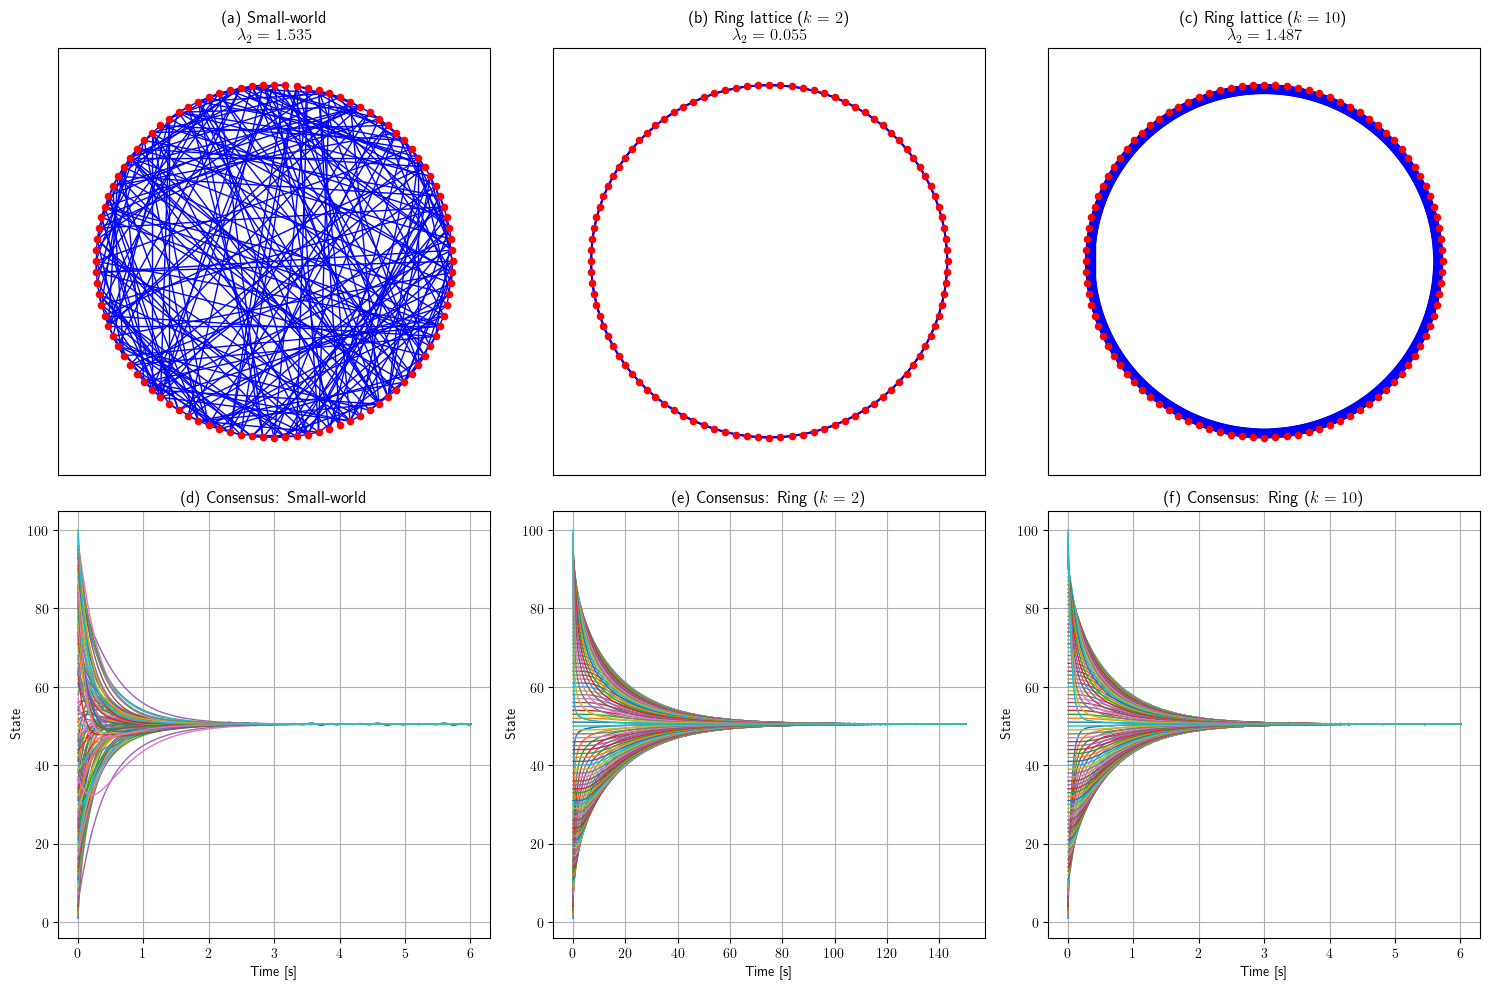

In [7]:
# ============================================================
# CREATE SYSTEMS
# ============================================================

small_world_100 = Consensus_Dynamics(
    number_of_nodes=100,
    k_nearest_neighbors=6,
    p=0.8
)

ring_sparse_100 = Consensus_Dynamics(
    number_of_nodes=100,
    k_nearest_neighbors=6,
    p=0.0
)

ring_dense_100 = Consensus_Dynamics(
    number_of_nodes=100,
    k_nearest_neighbors=20,
    p=0.0
)

# ============================================================
# DEFINE GRAPHS
# ============================================================

small_world_100.define_graph()
ring_sparse_100.define_graph()
ring_dense_100.define_graph()

# ============================================================
# SIMULATE
# ============================================================

small_world_100.Simulate_Consensus_Dynamics(t_final=6)

ring_sparse_100.Simulate_Consensus_Dynamics(t_final=150)

ring_dense_100.Simulate_Consensus_Dynamics(t_final=6)

# ============================================================
# PLOT RESULTS
# ============================================================

Plotting_results(list_of_graphs=[small_world_100,ring_sparse_100, ring_dense_100],
                 graph_titles=[r"(a) Small-world",r"(b) Ring lattice ($k=2$)",r"(c) Ring lattice ($k=10$)"],
                 consensus_titles=[r"(d) Consensus: Small-world", r"(e) Consensus: Ring ($k=2$)",r"(f) Consensus: Ring ($k=10$)"],
                 file_name="simulation_100_nodes")

Y, ahora, se presentan los resultados obtenidos al disminuir el número de nodos en las redes a 30:

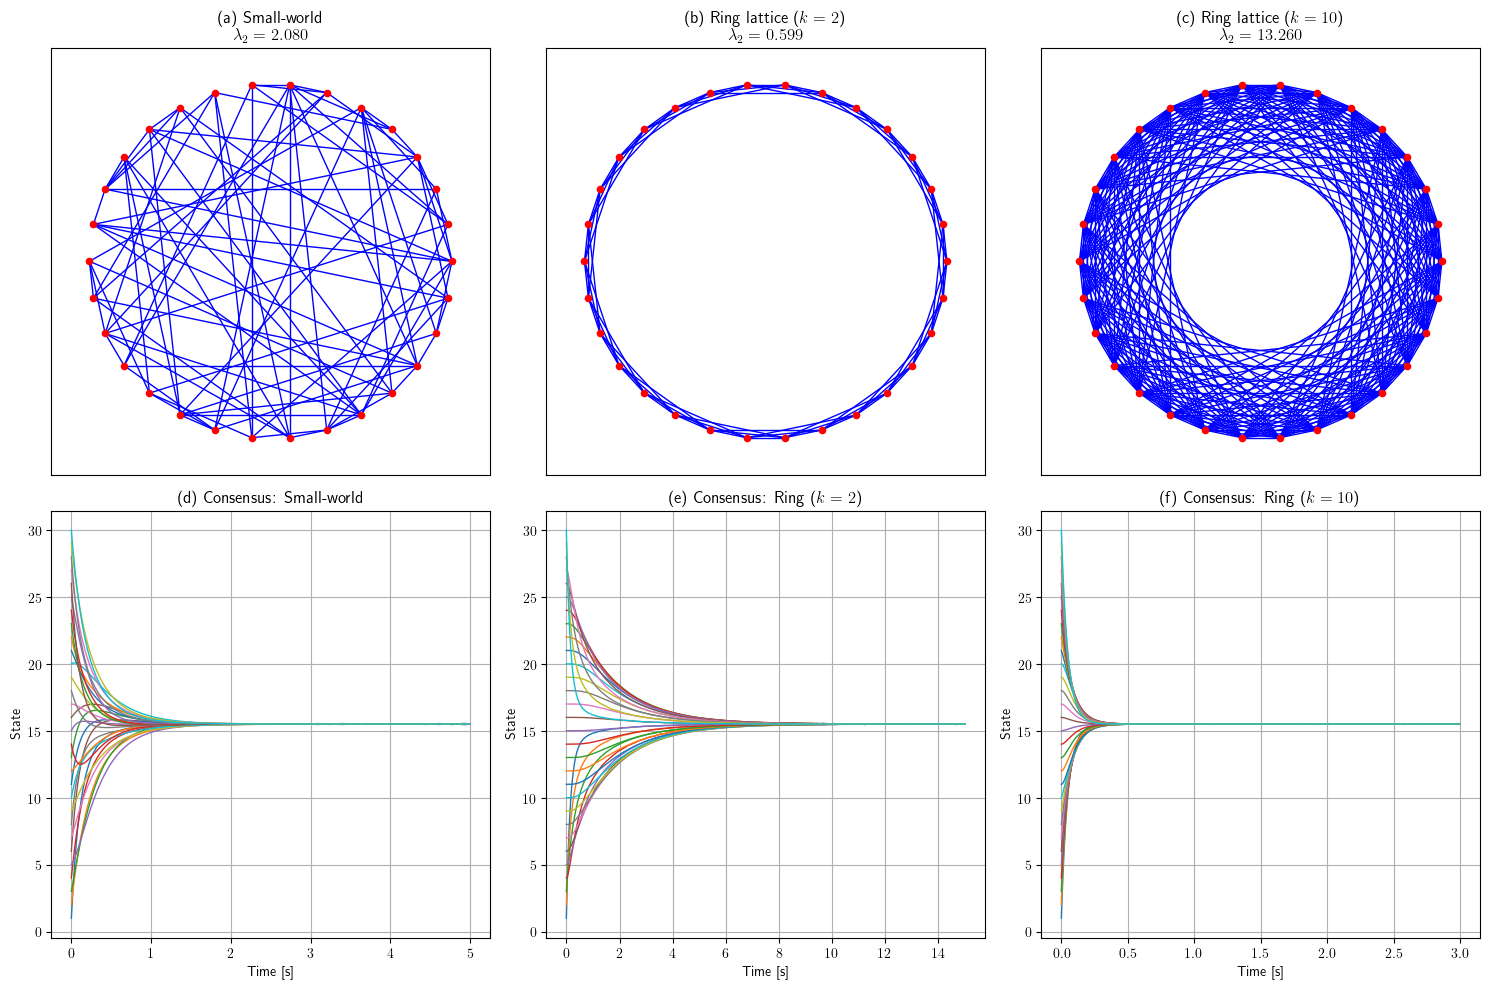

In [8]:
# ============================================================
# CREATE SYSTEMS
# ============================================================

small_world_30 = Consensus_Dynamics(
    number_of_nodes=30,
    k_nearest_neighbors=6,
    p=0.8
)

ring_sparse_30 = Consensus_Dynamics(
    number_of_nodes=30,
    k_nearest_neighbors=6,
    p=0.0
)

ring_dense_30 = Consensus_Dynamics(
    number_of_nodes=30,
    k_nearest_neighbors=20,
    p=0.0
)

# ============================================================
# DEFINE GRAPHS
# ============================================================

small_world_30.define_graph()
ring_sparse_30.define_graph()
ring_dense_30.define_graph()

# ============================================================
# SIMULATE
# ============================================================

small_world_30.Simulate_Consensus_Dynamics(t_final=5)

ring_sparse_30.Simulate_Consensus_Dynamics(t_final=15)

ring_dense_30.Simulate_Consensus_Dynamics(t_final=3)

# ============================================================
# PLOT RESULTS
# ============================================================

Plotting_results(list_of_graphs=[small_world_30,ring_sparse_30, ring_dense_30],
                 graph_titles=[r"(a) Small-world",r"(b) Ring lattice ($k=2$)",r"(c) Ring lattice ($k=10$)"],
                 consensus_titles=[r"(d) Consensus: Small-world", r"(e) Consensus: Ring ($k=2$)",r"(f) Consensus: Ring ($k=10$)"],
                 file_name="simulation_30_nodes")

**References**


[1] R. Olfati-Saber, J. A. Fax, and R. M. Murray, “Consensus and Cooperation in Networked Multi-Agent Systems,” Proceedings of the IEEE, vol. 95, no. 1, pp. 215–233, 2007, doi: 10.1109/JPROC.2006.887293.
  